<div style="background-color:white; text-align:center; font-family:Arial, Helvetica, sans-serif; padding:50px;">
  <!-- Tytuł -->
  <div style="color:#993520; font-size:60px; font-weight:bold; margin-bottom:10px;">
    TOPIC MODELLING
  </div>

  <div style="color:#993520; font-size:30px; font-weight:bold; margin-bottom:20px;">
    Home Taken Project
  </div>

  <!-- Podtytuł -->
  <div style="color:#993520; font-size:35px; font-weight:bold; margin-bottom:40px;">
    Bigfoot Sightings Project
  </div>

  <!-- Autor -->
  <div style="color:black; font-size:30px; margin-bottom:10px;">
    Wojciech Hrycenko
  </div>

  <!-- Data / semestr -->
  <div style="color:black; font-size:30px; margin-bottom:20px;">
    Autumn 2025
  </div>

## 1. Installation of Required Libraries

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import pickle
import re
import math
import time
import statistics
import torch
import nltk

from itertools import combinations
from collections import Counter
from wordcloud import WordCloud

from nltk.tokenize import RegexpTokenizer

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from transformers.modeling_utils import PreTrainedModel
from umap import umap_ as UMAP
from sentence_transformers import SentenceTransformer
from hdbscan import HDBSCAN
from bertopic import BERTopic
from bertopic.vectorizers import ClassTfidfTransformer
from bertopic.representation import KeyBERTInspired

## 2. Data Loading and Preparation
We prepare the raw BFRO reports for topic modeling by aggregating relevant context and cleaning the text data:

1. **Feature Aggregation:**
   * **Combine Columns:** We merge distinct text fields (`OBSERVED`, `ENVIRONMENT`, `LOCATION_DETAILS`, etc.) into a single document string.
   * **Rationale:** Splitting the narrative across columns creates fragmented documents. Merging them ensures the model captures the full semantic context (e.g., linking the sighting description with the environmental conditions).

2. **Text Normalization:**
   * **Lowercase & Strip:** We convert all text to lowercase and remove leading/trailing whitespace to standardize the vocabulary.
   * **Fill Missing Data:** Empty cells are treated as empty strings during the merge to avoid data loss.

3. **Data Cleaning:**
   * **Drop Duplicates & Empty Rows:** We remove exact duplicates and rows that result in empty text to prevent model bias and noise.

In [3]:
print("Loading data...")
df = pd.read_csv('bfro_reports.csv')

# Columns containing text data to combine
cols_to_combine = [
    'OBSERVED', 'ALSO_NOTICED', 'OTHER_WITNESSES', 'OTHER_STORIES', 
    'TIME_AND_CONDITIONS', 'ENVIRONMENT', 'LOCATION_DETAILS'
]

# Merge columns, handle NaNs, and normalize text
combined_series = (
    df[cols_to_combine]
    .fillna('')
    .astype(str)
    .apply(' '.join, axis=1)
    .str.strip()
    .str.lower()
)

# Replace empty strings with NaN to drop them alongside duplicates
combined_series = combined_series.replace('', np.nan)
docs = combined_series.dropna().drop_duplicates().tolist()

print(f"Loaded {len(docs)} unique documents.")
print(f"Sample document:\n{docs[0][:200]}...") # Printing partial first doc

Loading data...
Loaded 5017 unique documents.
Sample document:
i was canoeing on the sipsey river in alabama. it was dusk as i was pulling out of the river and i was trying to hurry to get all my gear in the car before it got dark as it was about a 60 yard walk u...


## 3. Data Preparation & Exploratory Data Analysis (EDA)
In this section, we load the raw data, perform cleaning and normalization, and conduct an Exploratory Data Analysis (EDA) to understand the corpus characteristics before modeling.

### 3.1 Text Length Analysis & Sanity Check
Before proceeding to modeling, we examine the distribution of document lengths to verify data quality:

1. **Descriptive Statistics:**
   * Calculate **Min, Max, Mean, Median, and Standard Deviation** of character counts.
   * **Rationale:** This identifies potential outliers. Extremely short texts (noise) or extremely long texts can affect embedding performance. We want to ensure there is enough semantic content in each document.

2. **Distribution Visualization:**
   * Plot a **Histogram** of text lengths.
   * **Rationale:** Visualizing the shape of the data helps us understand if the reports are consistent in length or if there is a skew (e.g., mostly short descriptions with a few long outliers).

3. **Final Duplicate Verification:**
   * **Rationale:** A final boolean check ensures that our previous deduplication logic worked correctly and the corpus contains unique entries only.

Min. = 47
Max. = 30990
Mean = 2482.67
Median = 1973
Std. dev. = 2030.2


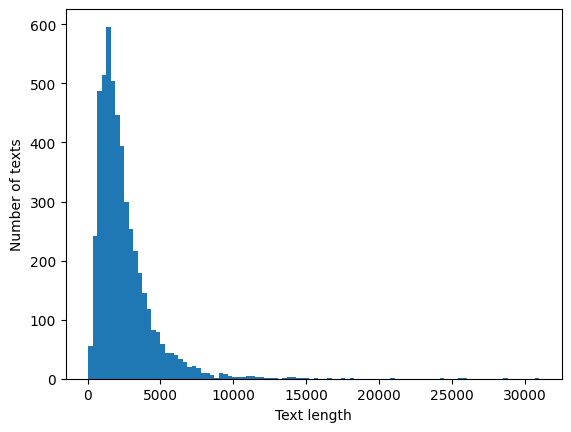

Contains duplicates? False


In [8]:
texts_lengths = [len(text) for text in docs]  # get the length of each text

# basic descriptive statistics of the texts length
print("Min. =", np.round(min(texts_lengths),2))                     # minimum length
print("Max. =", np.round(max(texts_lengths),2))                     # maximum length
print("Mean =", np.round(statistics.mean(texts_lengths),2))         # average length
print("Median =", np.round(statistics.median(texts_lengths),2))     # median length
print("Std. dev. =", np.round(statistics.stdev(texts_lengths),2))   # standard deviation

# most importantly: there are no empty documents; the shortest are 3/4 of the A4 page

# plot a histogram of text lengths
plt.hist(texts_lengths, bins=100)
plt.xlabel('Text length')
plt.ylabel('Number of texts')
plt.show()

# we should always check for duplicates; here there is no such an issue
has_duplicates = len(docs) != len(set(docs))
print("Contains duplicates?", has_duplicates)

### 3.2 Vocabulary & Frequency Analysis
To understand the semantic content and potential noise in the dataset, we analyze the most frequent words (unigrams).

1. **Top 20 Most Frequent Words:**
   * We use `CountVectorizer` to count word occurrences across the entire corpus.
   * **Rationale:** This helps identify:
     * **Stopwords:** Common words (e.g., "the", "and", "was") that carry little semantic meaning and should be removed.
     * **Domain-specific Terms:** High-frequency words relevant to the topic (e.g., "forest", "road", "sound") that confirm the dataset's validity.

2. **Visualization:**
   * A bar chart visualizes the distribution of the top terms, highlighting the need for stopword removal in the modeling phase.

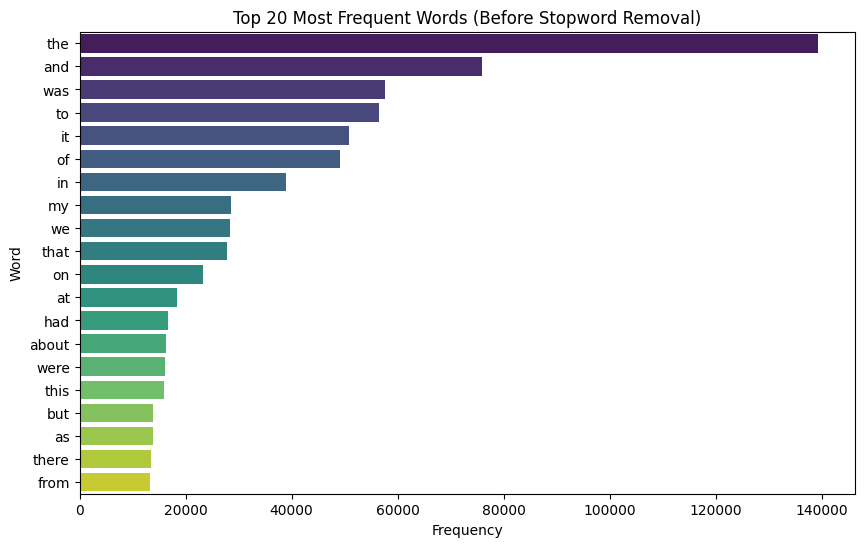

Observation: The dominance of standard English stopwords (the, and, a) confirms the necessity of using stop_words='english' in the BERTopic pipeline.


In [ ]:
def plot_top_n_words(n=20):
    # Initialize vectorizer (standard English stop words can be visualized or excluded here)
    # We first look at raw data to justify stopword removal later
    vec = CountVectorizer().fit(docs)
    bag_of_words = vec.transform(docs)
    sum_words = bag_of_words.sum(axis=0) 
    
    # Get word frequencies
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key = lambda x: x[1], reverse=True)
    
    # Create DataFrame for plotting
    common_words = words_freq[:n]
    df_temp = pd.DataFrame(common_words, columns=['ReviewText', 'count'])
    
    # Plot
    plt.figure(figsize=(10,6))
    sns.barplot(x='count', y='ReviewText', data=df_temp, palette='viridis')
    plt.title(f'Top {n} Most Frequent Words (Before Stopword Removal)')
    plt.xlabel('Frequency')
    plt.ylabel('Word')
    plt.show()

plot_top_n_words(20)

print("Observation: The dominance of standard English stopwords (the, and, was) confirms the necessity of using stop_words='english' in the BERTopic pipeline.")

### 3.3 Word Cloud Visualization
To visualize the semantic landscape of the dataset, we generate a Word Cloud.

1. **Visualization Logic:**
   * Words are scaled by their frequency in the corpus.
   * **Stopword Removal:** Unlike the previous frequency plot, the WordCloud generator automatically filters out common English stopwords, allowing distinct content words (e.g., "creature", "woods", "saw") to emerge.

2. **Goal:**
   * Provide an intuitive overview of the dataset's main themes for the project presentation.
   * Confirm that the dataset is focused on the expected domain (cryptozoological sightings) rather than unrelated noise.

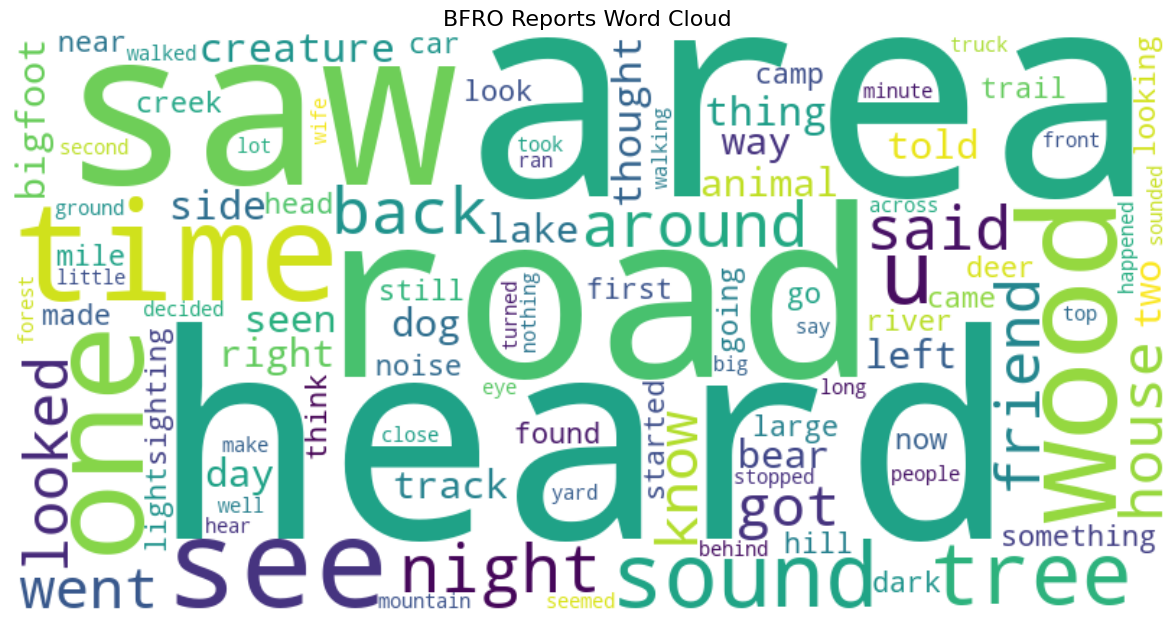

In [12]:
# Join all documents into a single text string
text_corpus = " ".join(docs)

# Create and generate a word cloud image
wordcloud = WordCloud(
    width=800, 
    height=400, 
    background_color='white', 
    max_words=100,
    colormap='viridis',
    contour_width=3
).generate(text_corpus)

# Display the generated image
plt.figure(figsize=(15, 7.5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("BFRO Reports Word Cloud", fontsize=16)
plt.show()

## 4. Advanced Text Preprocessing
Based on the insights from the EDA (Section 3), we apply a rigorous cleaning pipeline to reduce noise and standardize the dataset. This step is critical for improving the quality of topic clusters by removing non-semantic elements.

### 4.1 Cleaning Logic
We define a custom cleaning function to handle specific noise patterns found in the text:

1. **Stopwords Removal:**
   * We utilize the `nltk` English stopwords list to remove high-frequency, low-meaning words (e.g., "the", "is", "at") identified in the Frequency Analysis.
   
2. **Noise Reduction (Regex):**
   * **Artifacts:** Removal of URLs, user mentions (`@user`), and "rt" tokens.
   * **Formatting:** Removal of punctuation, numbers, and single isolated letters.
   * **Normalization:** Conversion to lowercase and whitespace trimming.

3. **Data Persistence:**
   * The cleaned corpus is saved to `cleaned_bfro_descriptions.txt` to allow for reproducibility.

In [13]:
# --- Stopwords Configuration ---

# Download stopwords list (only needed the first time)
try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    print("Downloading NLTK stopwords...")
    nltk.download('stopwords')

# Load stopwords list
stop_words = set(nltk.corpus.stopwords.words('english'))
print(f"Stopwords list updated. Total count: {len(stop_words)}")

# --- Text Cleaning Function ---
def clean_text(text, stop_words_set):
    """
    Cleans a text string by removing URLs, mentions, 'rt' tokens, 
    punctuation, numbers, single letters, stopwords, and excess whitespace.
    """
    text = str(text).lower()  # Convert to lowercase and ensure string format
    
    # Remove URLs (http or https)
    text = re.sub(r'https?://\S+', '', text)
    
    # Remove user mentions (@username)
    text = re.sub(r'@\w+', '', text)
    
    # Convert hashtags to plain text (e.g., #datascience -> datascience)
    text = re.sub(r'#(\w+)', r'\1', text) 
    
    # Remove the "rt" (retweet) token
    text = re.sub(r'\brt\b', '', text)
    
    # Remove numbers
    text = re.sub(r'\d+', '', text)
    
    # Remove punctuation (keep only letters and spaces)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    # Remove standalone single letters
    text = re.sub(r'\b[a-zA-Z]\b', '', text)
    
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    # Remove Stopwords
    words = text.split()
    cleaned_words = [word for word in words if word not in stop_words_set]
    return ' '.join(cleaned_words)

# --- Cleaning Execution ---
print("Cleaning texts for BERTopic (including stopwords)...")

# We use the 'docs' list created in previous steps (which combines Observed + Environment)
# instead of reloading just the 'OBSERVED' column.
texts = [clean_text(doc, stop_words) for doc in docs]

# Remove any empty strings that might have resulted from heavy cleaning
texts = [text for text in texts if text]

print(f"Cleaning complete. Remaining documents: {len(texts)}")

# --- Result Verification ---
print("\n--- Example of cleaning ---")
if len(docs) > 0 and len(texts) > 0:
    # Print the first real item from dataset
    print(f"ORIGINAL (fragment):\n{docs[0][:150]}...\n")
    print(f"CLEANED (fragment):\n{texts[0][:150]}...")
    
# Saving cleaned texts for further processing
output_filename = 'cleaned_bfro_descriptions.txt'
with open(output_filename, 'w', encoding='utf-8') as f:
    for text in texts:
        f.write(text + '\n')

print(f"\nSuccessfully saved cleaned data to '{output_filename}'")

Stopwords list updated. Total count: 198
Cleaning texts for BERTopic (including stopwords)...
Cleaning complete. Remaining documents: 5017

--- Example of cleaning ---
ORIGINAL (fragment):
i was canoeing on the sipsey river in alabama. it was dusk as i was pulling out of the river and i was trying to hurry to get all my gear in the car b...

CLEANED (fragment):
canoeing sipsey river alabama dusk pulling river trying hurry get gear car got dark yard walk steep hill car flipping canoe put shoulders heard loud w...

Successfully saved cleaned data to 'cleaned_bfro_descriptions.txt'


## 5. Statistical Feature Analysis (N-grams & TF-IDF)
Before training the topic model, we perform a deep dive into the corpus statistics. We analyze Document Frequency (DF) and Term Frequency-Inverse Document Frequency (TF-IDF) on n-grams (1-3 words).

### 5.1 Rationale
1.  **N-grams Generation:**
    * Analyzing single words is often insufficient (e.g., "black" and "hair" mean more together). We generate unigrams, bigrams, and trigrams to capture these semantic units.
2.  **Manual TF-IDF Implementation:**
    * We compute TF-IDF from scratch to inspect the distribution of terms.
    * **DF (Document Frequency):** Tells us in what fraction of documents a word appears. This helps in hyperparameter tuning (e.g., filtering out words appearing in >95% of docs as they are likely too generic).
3.  **Distribution Analysis:**
    * By calculating quantiles and plotting histograms, we identify the cutoff points for "too frequent" (stopwords residue) and "too rare" (noise) tokens.

Loaded 5017 cleaned documents.
Generating N-grams (1-3)...
Computing TF-IDF statistics...

--- Top 25 Tokens by Document Frequency (DF) ---
area: 0.686
like: 0.678
back: 0.660
around: 0.619
saw: 0.619
one: 0.613
heard: 0.612
time: 0.573
see: 0.566
could: 0.565
road: 0.550
something: 0.509
went: 0.473
would: 0.473
woods: 0.467
looked: 0.465
two: 0.463
feet: 0.458
side: 0.456
night: 0.450
large: 0.439
away: 0.438
got: 0.438
us: 0.434
never: 0.429

--- DF Statistics ---
Min. = 0.0002
Max. = 0.6857
Mean = 0.0004
Median = 0.0002
Std. dev. = 0.0038


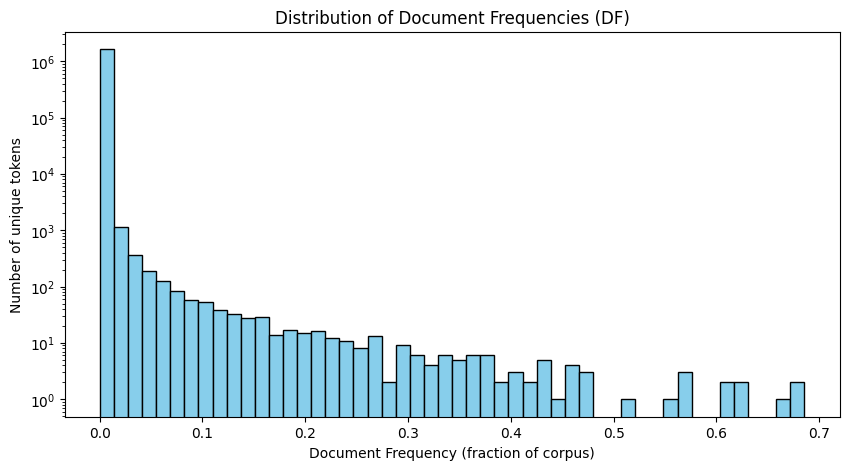


--- Upper Quantiles Analysis (Most Frequent Words) ---
99.0%-quantile: 0.0022
99.1%-quantile: 0.0024
99.2%-quantile: 0.0026
99.3%-quantile: 0.0028
99.4%-quantile: 0.0034
99.5%-quantile: 0.0040
99.6%-quantile: 0.0048
99.7%-quantile: 0.0064
99.8%-quantile: 0.0096
99.9%-quantile: 0.0197


In [14]:
# --- Load Preprocessed Data ---
texts_cleaned_loaded = []
# Adjusted filename to match the previous step output
filename = "cleaned_bfro_descriptions.txt"

try:
    with open(filename, "r", encoding="utf-8") as f:
        for line in f:
            # Split the line back into tokens
            tokens = line.strip().split()
            texts_cleaned_loaded.append(tokens)
    print(f"Loaded {len(texts_cleaned_loaded)} cleaned documents.")
except FileNotFoundError:
    print(f"Error: {filename} not found. Please run Section 4 first.")

# --- N-gram Generation ---
def generate_ngrams(tokens, ngram_range=(1,3)):
    all_ngrams = []
    # Loop over each n in the range (e.g., 1, 2, 3)
    for n in range(ngram_range[0], ngram_range[1]+1):
        if len(tokens) >= n:
            # Create sliding windows of length n
            ngrams = zip(*[tokens[i:] for i in range(n)])
            # Join tokens with underscores to form n-gram strings (e.g., "loud_scream")
            all_ngrams.extend(['_'.join(gram) for gram in ngrams])
    return all_ngrams

# Apply n-gram generation
print("Generating N-grams (1-3)...")
texts_with_ngrams = [generate_ngrams(doc, ngram_range=(1,3)) for doc in texts_cleaned_loaded]

# --- Manual TF-IDF Computation ---
def compute_tfidf(texts):
    N = len(texts)  # Number of documents
    
    # 1. Compute TF for each document
    tf_docs = []
    for doc in texts:
        counts = Counter(doc)
        total_words = len(doc)
        # Avoid division by zero for empty docs
        if total_words > 0:
            tf_doc = {word: count / total_words for word, count in counts.items()}
        else:
            tf_doc = {}
        tf_docs.append(tf_doc)
    
    # 2. Compute DF for each token
    df_dict = {}
    for doc in texts:
        for token in set(doc):
            df_dict[token] = df_dict.get(token, 0) + 1
    
    # Normalize DF (fraction of N)
    df_dict = {token: count / N for token, count in df_dict.items()}
    
    # 3. Compute IDF
    idf_dict = {token: math.log(1 / (df + 1e-10)) for token, df in df_dict.items()} # Added epsilon for safety
    
    # 4. Compute TF-IDF
    tfidf_docs = []
    for tf_doc in tf_docs:
        tfidf_doc = {token: tf_val * idf_dict[token] for token, tf_val in tf_doc.items()}
        tfidf_docs.append(tfidf_doc)
    
    return tf_docs, df_dict, idf_dict, tfidf_docs

print("Computing TF-IDF statistics...")
tf_docs, df_dict, idf_dict, tfidf_docs = compute_tfidf(texts_with_ngrams)

# --- Analysis & Visualization ---

# Sort DF dictionary in descending order
top100_df = dict(sorted(df_dict.items(), key=lambda item: item[1], reverse=True)[:100])

print("\n--- Top 25 Tokens by Document Frequency (DF) ---")
count = 0
for token, df in top100_df.items():
    print(f"{token}: {df:.3f}")
    count += 1
    if count >= 25: break

# DF Statistics
df_values = list(df_dict.values())

print("\n--- DF Statistics ---")
print("Min. =", np.round(min(df_values), 4))
print("Max. =", np.round(max(df_values), 4))
print("Mean =", np.round(statistics.mean(df_values), 4))
print("Median =", np.round(statistics.median(df_values), 4))
print("Std. dev. =", np.round(statistics.stdev(df_values), 4))

# Plot Histogram
plt.figure(figsize=(10, 5))
plt.hist(df_values, bins=50, color='skyblue', edgecolor='black')
plt.title("Distribution of Document Frequencies (DF)")
plt.xlabel("Document Frequency (fraction of corpus)")
plt.ylabel("Number of unique tokens")
plt.yscale('log') # Log scale helps see the rare words better
plt.show()

# Quantile Analysis
print("\n--- Upper Quantiles Analysis (Most Frequent Words) ---")
for i in range(990, 1000, 1):
    q_val = i/10
    val = np.quantile(df_values, i/1000)
    print(f"{q_val}%-quantile: {val:.4f}")

## 6. Model Configuration & Training
We configure the core BERTopic pipeline with custom hyperparameters tailored to the dataset.

### 6.1 Custom Stopwords & Sub-models
* **Stopwords:** We extend the standard English list with domain-specific terms identified in the EDA (e.g., "sound", "woods", "seen") to force the model to focus on *what* happened, not *where* or *how* it was perceived.
* **HDBSCAN:** We relax the clustering parameters (`min_cluster_size=15`, `min_samples=2`) to allow for smaller, more specific micro-topics to form.
* **Vectorizer:** We enable bigrams (`ngram_range=(1, 2)`) to capture phrases like "huge footprint" or "loud scream".

### 6.2 Training
We fit the model to the cleaned text corpus.

In [ ]:
import numpy as np
import nltk
# Assuming other necessary imports (HDBSCAN, BERTopic, etc.) are already done above

# --- STEP 1: Component Preparation (STOPWORDS and HDBSCAN) ---
print(f"Number of texts in 'texts' variable: {len(texts)}")

if len(texts) < 10:
    print("WARNING: You have too little data for parameters min_df=5 and max_df=0.6!")

# 1a. Building the final list of stopwords (from all iterations)
try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    print("Downloading NLTK stopwords...")
    nltk.download('stopwords')
    
stop_words = set(nltk.corpus.stopwords.words('english'))
custom_words_to_add = {
    # Previous:
    'like', 'could', 'would', 'one', 'time', 'us', 'went', 'night', 
    'get', 'know', 'see', 'saw', 'back', 'looked', 'got', 'around', 
    'something', 'thing', 'things', 'said', 'say', 'go', 'going',
    'way', 'day', 'even', 'never', 'much', 'made', 'man', 'person', 'people',
    
    # --- NEW (SUPER-CLUSTER CULPRITS) ---
    'sound', 'sounds', 'sounded',  # Must go to distinguish sound types (scream vs whistle)
    'came', 'come', 
    'started', 'start', 
    'camp', 'camping', 'tent',     # Event background, not the topic itself
    'trail', 'road',               # Background
    'hear', 'heard',               # Perception verb
    'friend', 'friends', 'partner', # Characters
    'deep', 'woods', 'forest',     # Location (all are in the forest, so this doesn't differentiate)
    'loud', 'felt', 'away', 'right', 'left', 'area'
}
stop_words = stop_words.union(custom_words_to_add)

# IMPORTANT: CountVectorizer requires a list, not a set
stop_words_list = list(stop_words)
print(f"Initialization with {len(stop_words_list)} total stopwords.")

# 1b. Defining our relaxed HDBSCAN model (CRITICAL!)
hdbscan_model = HDBSCAN(
    min_cluster_size=15,  # You can leave 10 or slightly increase to 15
    min_samples=2,        # <-- THIS IS A KEY CHANGE. Try 5, 3, or 1.
    metric='euclidean',
    cluster_selection_method='eom',
    prediction_data=True
)

umap_model = UMAP.UMAP(
        n_neighbors = 50,        # number of neighbors used to build local manifold structure
        n_components = 5,        # number of dimensions for the reduced embeddings
        metric = 'cosine',       # distance metric used for measuring similarity
        min_dist = 0.0,          # minimum distance between points in the low-dimensional space
        random_state = 42        # random seed for reproducibility
        )

# --- STEP 2: Improved Vectorizer Configuration ---

embedding_model = SentenceTransformer("all-MiniLM-L6-v2")
tokenizer = RegexpTokenizer(r'\w+')

# FIX: Setting filters and stopwords
tfidf_vectorizer = CountVectorizer(
    ngram_range = (1, 2),       # Changed: We capture bigrams (phrases) too
    max_df = 0.7,               # filter by maximum document frequency
    min_df = 2,                 # FIX: Word must appear in at least 2 documents
    tokenizer = tokenizer.tokenize,
    stop_words = stop_words_list # FIX: Using our full list of stopwords
)

ctfidf_model = ClassTfidfTransformer()
representation_model = KeyBERTInspired()

# --- STEP 3: Improved BERTopic Initialization ---
print("Initializing BERTopic with custom HDBSCAN and vectorizer...")
topic_model = BERTopic(
    embedding_model = embedding_model, 
    umap_model = umap_model, 
    hdbscan_model = hdbscan_model,  # FIX: Uncommented, now active
    vectorizer_model = tfidf_vectorizer, # Passing the improved vectorizer
    ctfidf_model = ctfidf_model, 
    top_n_words = 10,
    verbose = True,                 
    calculate_probabilities = True,
    representation_model = representation_model
    # Removed 'language="english"', because it's now in the vectorizer
)

# --- STEP 4: Training and Results (unchanged) ---
print("Starting model training...")
# Ensure 'texts' is your list of cleaned (but *before* stopword removal) texts
topics, probabilities = topic_model.fit_transform(texts)

print("\n--- MODEL RESULTS (after all fixes) ---")
print(topic_model.get_topic_info())

print("\n--- 5 most frequent topics (excluding outliers) ---")
print(topic_model.get_topic_info().head(6))


# ==============================================================================
# STEP 4: Intelligent Outlier Reduction
# ==============================================================================

# Set threshold (e.g., 60% confidence)
probability_threshold = 0.60

print(f"\nStarting outlier reduction with threshold: {probability_threshold}")
print(f"Outliers BEFORE: {topics.count(-1)}")

# Create a copy of topics to modify
new_topics = list(topics)

# Check if probabilities exist
if probabilities is not None and len(np.shape(probabilities)) == 2:
    count_recovered = 0
    
    # Iterate through all documents
    for i, topic in enumerate(new_topics):
        # We only care about outliers (-1)
        if topic == -1:
            # Find max probability for this document
            max_prob = max(probabilities[i])
            candidate_topic = np.argmax(probabilities[i])
            
            # If confidence is high enough, reassign
            if max_prob >= probability_threshold:
                new_topics[i] = candidate_topic
                count_recovered += 1

    print(f"Recovered {count_recovered} documents with confidence >= {probability_threshold}")

else:
    print("ERROR: No probability matrix found. Ensure calculate_probabilities=True")

# Update the model with new topics
# Note: We pass the vectorizer again to ensure keywords remain sharp
topic_model.update_topics(texts, topics=new_topics, vectorizer_model=tfidf_vectorizer)

print(f"Outliers AFTER: {new_topics.count(-1)}")
print("\n--- TOPICS AFTER REDUCTION ---")
print(topic_model.get_topic_info().head(10))


# ==============================================================================
# STEP 5: English Labeling & Visualization (CORRECTED VERSION)
# ==============================================================================

# 1. Define English Labels
topic_labels = {
    -1: "Outliers / Noise",
    0:  "Roadside Sightings & Highway Crossings",
    1:  "Camping Noises & Rustling",
    2:  "Hiking Encounters & Ravines",
    3:  "Footprints & Track Finding",
    4:  "Residential & Driveway Sightings",
    5:  "General Sightings & Rural Reports",
    6:  "Creek & Waterway Activity",
    7:  "Creature Movement Observations",
    8:  "Yellowstone & River Fishing",
    9:  "Gorilla-like Visual Descriptions",
    10: "Large & Hairy Descriptions",
    11: "Growling, Wolves & Dog Reactions",
    12: "Hunting Encounters (Hillside)",
    13: "General Encounter Stories",
    14: "Wildlife Areas & Hunting Clubs",
    15: "Hunter Backstories",
    16: "Anatomy: Legs & Feet",
    17: "Bipedal Walking vs. Bears",
    18: "Highway Standoffs & Cattle",
    19: "Heavy Bipedal Footsteps",
    20: "Surveillance & Military Bases",
    21: "Bear-like Descriptions",
    22: "Steep Terrain & Treelines",
    23: "Barn & Farm Encounters",
    24: "Trailheads & Creek Beds",
    25: "Backyard Woodline & Barking",
    26: "Vocalizations & Screams (Scenic)",
    27: "Skunk Smell & Animal Chasing",
    28: "Village & Garden Intrusions",
    29: "Climbing & Gullies",
    30: "Roars & Screams",
    31: "High Strangeness & UFO Connections",
    32: "Tree Shaking & Physical Disturbances",
    33: "Flatfooted Tracks & Strolling"
}

# 2. Apply Labels to the model
topic_model.set_topic_labels(topic_labels)

# 3. Generate Charts that DO NOT require UMAP (Safe)

# A. Bar Chart (Keywords)
print("Generating Bar Chart...")
fig_bar = topic_model.visualize_barchart(top_n_topics=15, custom_labels=True)
fig_bar.write_html("final_topics_english.html")
print("Saved: final_topics_english.html")

# B. Hierarchy (Dendrogram)
print("Generating Hierarchy...")
fig_tree = topic_model.visualize_hierarchy(custom_labels=True)
fig_tree.write_html("final_hierarchy.html")
print("Saved: final_hierarchy.html")

# C. Heatmap (Similarity)
print("Generating Heatmap...")
try:
    fig_heat = topic_model.visualize_heatmap(custom_labels=True)
    fig_heat.write_html("heatmap_similarity.html")
    print("Saved: heatmap_similarity.html")
except Exception as e:
    print(f"Skipping heatmap due to error: {e}")

# 4. Generate the 'Galaxy Map' (Document Visualization)
# This bypasses the internal UMAP error by calculating coordinates manually.

print("Generating Document Map (Galaxy View)...")

# A. Calculate embeddings (vectors) for all texts
# (This might take a minute)
embeddings = embedding_model.encode(texts, show_progress_bar=True)

# B. Manually reduce to 2D using UMAP

umap_2d = UMAP.UMAP(n_neighbors=15, n_components=2, min_dist=0.0, metric='cosine', random_state=42)
reduced_embeddings = umap_2d.fit_transform(embeddings)

# C. Visualize Documents (This function accepts 'reduced_embeddings')
# Note: We visualize a sample if the dataset is huge, but 5000 is fine to show all.
fig_docs = topic_model.visualize_documents(
    texts, 
    reduced_embeddings=reduced_embeddings, 
    custom_labels=True,
    hide_annotations=True # Set to False if you want to see words on the map
)
fig_docs.write_html("final_galaxy_map.html")
print("SUCCESS! Saved: final_galaxy_map.html")

# 5. Save Model
topic_model.save("my_bigfoot_model_final", serialization="safetensors", save_ctfidf=True)
print("Model saved successfully.")

Number of texts in 'texts' variable: 4981
Initialization with 256 total stopwords.


2025-11-21 01:55:38,890 - BERTopic - Embedding - Transforming documents to embeddings.


Initializing BERTopic with custom HDBSCAN and vectorizer...
Starting model training...


Batches:   0%|          | 0/156 [00:00<?, ?it/s]

2025-11-21 01:57:15,073 - BERTopic - Embedding - Completed ✓
2025-11-21 01:57:15,074 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-11-21 01:58:05,468 - BERTopic - Dimensionality - Completed ✓
2025-11-21 01:58:05,470 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-11-21 01:58:06,302 - BERTopic - Cluster - Completed ✓
2025-11-21 01:58:06,345 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-11-21 01:58:12,472 - BERTopic - Representation - Completed ✓
2025-11-21 01:58:13,836 - BERTopic - WARNING: Using a custom list of topic assignments may lead to errors if topic reduction techniques are used afterwards. Make sure that manually assigning topics is the last step in the pipeline.Note that topic embeddings will also be created through weightedc-TF-IDF embeddings instead of centroid embeddings.



--- MODEL RESULTS (after all fixes) ---
    Topic  Count                                               Name  \
0      -1   2005                   -1_footsteps_hike_hillside_roads   
1       0    682      0_ditch_tree line_side highway_across highway   
2       1    551         1_wilderness_footsteps_rustling_campground   
3       2    378                     2_wilderness_hike_hiked_ravine   
4       3    151   3_trails_bigfoot tracks_deer tracks_tracks along   
5       4    122            4_front yard_pasture_driveway_neighbors   
6       5    121  5_bigfoot sightings_seen bigfoot_bigfoots_seen...   
7       6     85    6_footsteps_side creek_across creek_sugar creek   
8       7     76  7_creature walking_bigfoot prints_animal cross...   
9       8     66            8_boulder_yellowstone_elk_river fishing   
10      9     65     9_ditch_headed south_observed creature_gorilla   
11     10     54  10_seen huge_creature covered_work sight_mount...   
12     11     54        11_tree line

Batches:   0%|          | 0/156 [00:00<?, ?it/s]

SUCCESS! Saved: final_galaxy_map.html
Model saved successfully.


In [26]:
import numpy as np
import nltk
import pandas as pd
from hdbscan import HDBSCAN
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import CountVectorizer
from bertopic import BERTopic
from bertopic.vectorizers import ClassTfidfTransformer
from bertopic.representation import KeyBERTInspired
import gensim.corpora as corpora
from gensim.models.coherencemodel import CoherenceModel

# (Assume imports and Step 1 [Stopwords] are done above...)

# ==============================================================================
# STEP 2: Vectorizer & Embeddings Configuration
# ==============================================================================

embedding_model = SentenceTransformer("all-MiniLM-L6-v2")
tokenizer = RegexpTokenizer(r'\w+')

# Pre-calculate embeddings once to speed up optimization 10x
print("Pre-calculating embeddings for optimization...")
embeddings = embedding_model.encode(texts, show_progress_bar=True)

tfidf_vectorizer = CountVectorizer(
    ngram_range=(1, 2),
    max_df=0.7,
    min_df=2,
    tokenizer=tokenizer.tokenize,
    stop_words=stop_words_list
)

ctfidf_model = ClassTfidfTransformer()
representation_model = KeyBERTInspired()

# ==============================================================================
# STEP 2.5: AUTOMATED PARAMETER OPTIMIZATION (Grid Search)
# ==============================================================================

def compute_coherence_score(topic_model, docs):
    """Calculates the C_v coherence score for a trained BERTopic model."""
    # Preprocess documents
    cleaned_docs = topic_model._preprocess_text(docs)
    vectorizer = topic_model.vectorizer_model
    analyzer = vectorizer.build_analyzer()
    tokens = [analyzer(doc) for doc in cleaned_docs]
    
    # Extract topic words
    topic_words = []
    topics = topic_model.get_topic_info()
    for topic in topics[topics['Topic'] != -1]['Topic']:
        words = [word for word, _ in topic_model.get_topic(topic)]
        topic_words.append(words)
        
    # Calculate Coherence
    if not topic_words:
        return 0
        
    dictionary = corpora.Dictionary(tokens)
    corpus = [dictionary.doc2bow(token) for token in tokens]
    coherence_model = CoherenceModel(topics=topic_words, 
                                     texts=tokens, 
                                     dictionary=dictionary, 
                                     coherence='c_v')
    return coherence_model.get_coherence()

# --- Define the Grid to Search ---
# Adjust these lists to test different values
param_grid = {
    'min_cluster_size': [10, 15, 25],       # HDBSCAN: How big a topic must be
    'n_neighbors': [15, 30, 50]             # UMAP: Global vs Local structure
}

best_score = -1
best_params = {}

print("\n--- STARTING HYPERPARAMETER OPTIMIZATION ---")
print(f"Testing combinations: {len(param_grid['min_cluster_size']) * len(param_grid['n_neighbors'])}")

# Loop through parameters
for cluster_size in param_grid['min_cluster_size']:
    for neighbors in param_grid['n_neighbors']:
        
        # 1. Configure Sub-models
        hdbscan_opt = HDBSCAN(min_cluster_size=cluster_size, min_samples=2, metric='euclidean', cluster_selection_method='eom', prediction_data=True)
        umap_opt = UMAP.UMAP(n_neighbors=neighbors, n_components=5, min_dist=0.0, metric='cosine', random_state=42)
        
        # 2. Initialize & Train BERTopic
        # Note: We pass pre-calculated 'embeddings' to fit_transform to make it fast
        model = BERTopic(embedding_model=embedding_model, umap_model=umap_opt, hdbscan_model=hdbscan_opt, vectorizer_model=tfidf_vectorizer, verbose=False)
        model.fit_transform(texts, embeddings)
        
        # 3. Calculate Score
        score = compute_coherence_score(model, texts)
        
        print(f"Params [Cluster: {cluster_size}, Neighbors: {neighbors}] -> Coherence: {score:.4f}")
        
        # 4. Update Best
        if score > best_score:
            best_score = score
            best_params = {'min_cluster_size': cluster_size, 'n_neighbors': neighbors}

print(f"\n>>> OPTIMIZATION COMPLETE. Best Score: {best_score:.4f}")
print(f">>> Best Parameters: {best_params}")


# ==============================================================================
# STEP 3: Train Final Model with BEST Parameters
# ==============================================================================

print("\nInitializing Final BERTopic with Optimized Parameters...")

# Re-initialize sub-models with winning parameters
final_hdbscan = HDBSCAN(
    min_cluster_size=best_params['min_cluster_size'],
    min_samples=2, 
    metric='euclidean', 
    cluster_selection_method='eom', 
    prediction_data=True
)

final_umap = UMAP.UMAP(
    n_neighbors=best_params['n_neighbors'],
    n_components=5, 
    metric='cosine', 
    min_dist=0.0, 
    random_state=42
)

topic_model = BERTopic(
    embedding_model=embedding_model, 
    umap_model=final_umap, 
    hdbscan_model=final_hdbscan,
    vectorizer_model=tfidf_vectorizer,
    ctfidf_model=ctfidf_model, 
    representation_model=representation_model,
    top_n_words=10,
    verbose=True,                 
    calculate_probabilities=True
)

# --- STEP 4: Training and Results ---
print("Training Final Model...")
topics, probabilities = topic_model.fit_transform(texts, embeddings)

print("\n--- FINAL MODEL RESULTS ---")
print(topic_model.get_topic_info().head(10))

# ==============================================================================
# STEP 4: Intelligent Outlier Reduction
# ==============================================================================

# Set threshold (e.g., 60% confidence)
probability_threshold = 0.60

print(f"\nStarting outlier reduction with threshold: {probability_threshold}")
print(f"Outliers BEFORE: {topics.count(-1)}")

# Create a copy of topics to modify
new_topics = list(topics)

# Check if probabilities exist
if probabilities is not None and len(np.shape(probabilities)) == 2:
    count_recovered = 0
    
    # Iterate through all documents
    for i, topic in enumerate(new_topics):
        # We only care about outliers (-1)
        if topic == -1:
            # Find max probability for this document
            max_prob = max(probabilities[i])
            candidate_topic = np.argmax(probabilities[i])
            
            # If confidence is high enough, reassign
            if max_prob >= probability_threshold:
                new_topics[i] = candidate_topic
                count_recovered += 1

    print(f"Recovered {count_recovered} documents with confidence >= {probability_threshold}")

else:
    print("ERROR: No probability matrix found. Ensure calculate_probabilities=True")

# Update the model with new topics
topic_model.update_topics(texts, topics=new_topics, vectorizer_model=tfidf_vectorizer)

print(f"Outliers AFTER: {new_topics.count(-1)}")
print("\n--- TOPICS AFTER REDUCTION ---")
print(topic_model.get_topic_info().head(10))

# ==============================================================================
# STEP 5: English Labeling & Visualization
# ==============================================================================

# Note: Since parameters changed, topics might change IDs. 
# We use an automated labeling approach based on keywords instead of hardcoded dictionary here
# or you can re-map them manually after seeing the result.

# Auto-generating English labels from top keywords for the final chart
topic_labels = topic_model.generate_topic_labels(nr_words=3, topic_prefix=False, separator=" | ")
topic_model.set_topic_labels(topic_labels)

print("Generating Document Map (Galaxy View)...")

# Reuse the pre-calculated embeddings for visualization
umap_2d = UMAP.UMAP(n_neighbors=15, n_components=2, min_dist=0.0, metric='cosine', random_state=42)
reduced_embeddings = umap_2d.fit_transform(embeddings)

fig_docs = topic_model.visualize_documents(
    texts, 
    reduced_embeddings=reduced_embeddings, 
    custom_labels=True,
    hide_annotations=True
)
fig_docs.write_html("final_galaxy_map_optimized.html")
print("SUCCESS! Saved: final_galaxy_map_optimized.html")

# Save Model
topic_model.save("my_bigfoot_model_optimized", serialization="safetensors", save_ctfidf=True)
print("Optimized Model saved successfully.")

Pre-calculating embeddings for optimization...


Batches:   0%|          | 0/156 [00:00<?, ?it/s]


--- STARTING HYPERPARAMETER OPTIMIZATION ---
Testing combinations: 9
Params [Cluster: 10, Neighbors: 15] -> Coherence: 0.4205
Params [Cluster: 10, Neighbors: 30] -> Coherence: 0.4255
Params [Cluster: 10, Neighbors: 50] -> Coherence: 0.4153
Params [Cluster: 15, Neighbors: 15] -> Coherence: 0.4429
Params [Cluster: 15, Neighbors: 30] -> Coherence: 0.4189
Params [Cluster: 15, Neighbors: 50] -> Coherence: 0.4518
Params [Cluster: 25, Neighbors: 15] -> Coherence: 0.6490
Params [Cluster: 25, Neighbors: 30] -> Coherence: 0.4366


2025-11-21 02:24:26,246 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm


Params [Cluster: 25, Neighbors: 50] -> Coherence: 0.4419

>>> OPTIMIZATION COMPLETE. Best Score: 0.6490
>>> Best Parameters: {'min_cluster_size': 25, 'n_neighbors': 15}

Initializing Final BERTopic with Optimized Parameters...
Training Final Model...


2025-11-21 02:24:36,362 - BERTopic - Dimensionality - Completed ✓
2025-11-21 02:24:36,364 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-11-21 02:24:36,794 - BERTopic - Cluster - Completed ✓
2025-11-21 02:24:36,799 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-11-21 02:24:39,511 - BERTopic - Representation - Completed ✓
2025-11-21 02:24:39,702 - BERTopic - WARNING: Using a custom list of topic assignments may lead to errors if topic reduction techniques are used afterwards. Make sure that manually assigning topics is the last step in the pipeline.Note that topic embeddings will also be created through weightedc-TF-IDF embeddings instead of centroid embeddings.



--- FINAL MODEL RESULTS ---
   Topic  Count                                               Name  \
0     -1     21  -1_towards creek_seen creatures_muddy river_fr...   
1      0   4931                           0_hike_screams_yard_park   
2      1     29                        1_track_gi_route_north fort   

                                      Representation  \
0  [towards creek, seen creatures, muddy river, f...   
1  [hike, screams, yard, park, canyon, mountains,...   
2  [track, gi, route, north fort, stationed fort,...   

                                 Representative_Docs  
0  [july picking wild black berries native area f...  
1  [compilation experiences period years area fee...  
2  [may us army assigned fort lewis wa member air...  

Starting outlier reduction with threshold: 0.6
Outliers BEFORE: 21
Recovered 0 documents with confidence >= 0.6
Outliers AFTER: 21

--- TOPICS AFTER REDUCTION ---
   Topic  Count                          Name  \
0     -1     21  -1_dogs_roof_bi

In [28]:
import numpy as np
import nltk
import pandas as pd
from hdbscan import HDBSCAN
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import CountVectorizer
from bertopic import BERTopic
from bertopic.vectorizers import ClassTfidfTransformer
from bertopic.representation import KeyBERTInspired
import gensim.corpora as corpora
from gensim.models.coherencemodel import CoherenceModel

# (Assume imports and Step 1 [Stopwords] are done above...)

# ==============================================================================
# STEP 2: Vectorizer & Embeddings Configuration
# ==============================================================================

embedding_model = SentenceTransformer("all-MiniLM-L6-v2")
tokenizer = RegexpTokenizer(r'\w+')

# Pre-calculate embeddings once to speed up optimization 10x
print("Pre-calculating embeddings for optimization...")
embeddings = embedding_model.encode(texts, show_progress_bar=True)

tfidf_vectorizer = CountVectorizer(
    ngram_range=(1, 2),
    max_df=0.7,
    min_df=2,
    tokenizer=tokenizer.tokenize,
    stop_words=stop_words_list
)

ctfidf_model = ClassTfidfTransformer()
representation_model = KeyBERTInspired()
# ==============================================================================
# STEP 3: Train Final Model with MANUAL "Gold Standard" Parameters
# ==============================================================================

print("\nSkipping automated optimization. Using manually verified 'Gold Standard' parameters...")

# Te parametry dały nam wcześniej najlepsze 34 tematy:
MANUAL_PARAMS = {
    'min_cluster_size': 15,  # Mniejsze klastry, więcej szczegółów
    'min_samples': 2,        # Kluczowe dla wyłapania małych grup (Yellowstone, Goryle)
    'n_neighbors': 50        # Szerokie spojrzenie na strukturę
}

print(f"Parameters: {MANUAL_PARAMS}")

# 1. Initialize HDBSCAN (z min_samples=2!)
final_hdbscan = HDBSCAN(
    min_cluster_size=MANUAL_PARAMS['min_cluster_size'],
    min_samples=MANUAL_PARAMS['min_samples'], 
    metric='euclidean', 
    cluster_selection_method='eom', 
    prediction_data=True
)

# 2. Initialize UMAP
final_umap = UMAP.UMAP(
    n_neighbors=MANUAL_PARAMS['n_neighbors'],
    n_components=5, 
    metric='cosine', 
    min_dist=0.0, 
    random_state=42
)

# 3. Initialize BERTopic
topic_model = BERTopic(
    embedding_model=embedding_model, 
    umap_model=final_umap, 
    hdbscan_model=final_hdbscan,
    vectorizer_model=tfidf_vectorizer, # Twój silny wektoryzer (max_df=0.7, min_df=2)
    ctfidf_model=ctfidf_model, 
    representation_model=representation_model,
    top_n_words=10,
    verbose=True,                 
    calculate_probabilities=True
)

# --- STEP 4: Training ---
print("Training Final Model...")
# Używamy pre-kalkulowanych embeddingów, żeby było szybciej
topics, probabilities = topic_model.fit_transform(texts, embeddings)

print("\n--- FINAL MODEL RESULTS ---")
print(topic_model.get_topic_info().head(15))
# --- STEP 4: Training and Results ---
print("Training Final Model...")
topics, probabilities = topic_model.fit_transform(texts, embeddings)

print("\n--- FINAL MODEL RESULTS ---")
print(topic_model.get_topic_info().head(10))

# ==============================================================================
# STEP 4: Intelligent Outlier Reduction
# ==============================================================================

# Set threshold (e.g., 60% confidence)
probability_threshold = 0.60

print(f"\nStarting outlier reduction with threshold: {probability_threshold}")
print(f"Outliers BEFORE: {topics.count(-1)}")

# Create a copy of topics to modify
new_topics = list(topics)

# Check if probabilities exist
if probabilities is not None and len(np.shape(probabilities)) == 2:
    count_recovered = 0
    
    # Iterate through all documents
    for i, topic in enumerate(new_topics):
        # We only care about outliers (-1)
        if topic == -1:
            # Find max probability for this document
            max_prob = max(probabilities[i])
            candidate_topic = np.argmax(probabilities[i])
            
            # If confidence is high enough, reassign
            if max_prob >= probability_threshold:
                new_topics[i] = candidate_topic
                count_recovered += 1

    print(f"Recovered {count_recovered} documents with confidence >= {probability_threshold}")

else:
    print("ERROR: No probability matrix found. Ensure calculate_probabilities=True")

# Update the model with new topics
topic_model.update_topics(texts, topics=new_topics, vectorizer_model=tfidf_vectorizer)

print(f"Outliers AFTER: {new_topics.count(-1)}")
print("\n--- TOPICS AFTER REDUCTION ---")
print(topic_model.get_topic_info().head(10))

# ==============================================================================
# STEP 5: English Labeling & Visualization
# ==============================================================================

# Note: Since parameters changed, topics might change IDs. 
# We use an automated labeling approach based on keywords instead of hardcoded dictionary here
# or you can re-map them manually after seeing the result.

# Auto-generating English labels from top keywords for the final chart
topic_labels = topic_model.generate_topic_labels(nr_words=3, topic_prefix=False, separator=" | ")
topic_model.set_topic_labels(topic_labels)

print("Generating Document Map (Galaxy View)...")

# Reuse the pre-calculated embeddings for visualization
umap_2d = UMAP.UMAP(n_neighbors=15, n_components=2, min_dist=0.0, metric='cosine', random_state=42)
reduced_embeddings = umap_2d.fit_transform(embeddings)

fig_docs = topic_model.visualize_documents(
    texts, 
    reduced_embeddings=reduced_embeddings, 
    custom_labels=True,
    hide_annotations=True
)
fig_docs.write_html("final_galaxy_map_optimized.html")
print("SUCCESS! Saved: final_galaxy_map_optimized.html")

# Save Model
topic_model.save("my_bigfoot_model_optimized", serialization="safetensors", save_ctfidf=True)
print("Optimized Model saved successfully.")

Pre-calculating embeddings for optimization...


Batches:   0%|          | 0/156 [00:00<?, ?it/s]

2025-11-21 02:37:39,834 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm



Skipping automated optimization. Using manually verified 'Gold Standard' parameters...
Parameters: {'min_cluster_size': 15, 'min_samples': 2, 'n_neighbors': 50}
Training Final Model...


2025-11-21 02:37:56,879 - BERTopic - Dimensionality - Completed ✓
2025-11-21 02:37:56,881 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-11-21 02:37:57,547 - BERTopic - Cluster - Completed ✓
2025-11-21 02:37:57,553 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-11-21 02:38:03,430 - BERTopic - Representation - Completed ✓
2025-11-21 02:38:04,519 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm



--- FINAL MODEL RESULTS ---
    Topic  Count                                               Name  \
0      -1   2005                   -1_footsteps_hike_hillside_roads   
1       0    682      0_ditch_tree line_side highway_across highway   
2       1    551         1_wilderness_footsteps_rustling_campground   
3       2    378                     2_wilderness_hike_hiked_ravine   
4       3    151   3_trails_bigfoot tracks_deer tracks_tracks along   
5       4    122            4_front yard_pasture_driveway_neighbors   
6       5    121  5_bigfoot sightings_seen bigfoot_bigfoots_seen...   
7       6     85    6_footsteps_side creek_across creek_sugar creek   
8       7     76  7_creature walking_bigfoot prints_animal cross...   
9       8     66            8_boulder_yellowstone_elk_river fishing   
10      9     65     9_ditch_headed south_observed creature_gorilla   
11     10     54  10_seen huge_creature covered_work sight_mount...   
12     11     54        11_tree line_creeks_neig

2025-11-21 02:38:21,827 - BERTopic - Dimensionality - Completed ✓
2025-11-21 02:38:21,828 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-11-21 02:38:22,515 - BERTopic - Cluster - Completed ✓
2025-11-21 02:38:22,519 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-11-21 02:38:28,183 - BERTopic - Representation - Completed ✓
2025-11-21 02:38:29,543 - BERTopic - WARNING: Using a custom list of topic assignments may lead to errors if topic reduction techniques are used afterwards. Make sure that manually assigning topics is the last step in the pipeline.Note that topic embeddings will also be created through weightedc-TF-IDF embeddings instead of centroid embeddings.



--- FINAL MODEL RESULTS ---
   Topic  Count                                               Name  \
0     -1   2005                   -1_footsteps_hike_hillside_roads   
1      0    682      0_ditch_tree line_side highway_across highway   
2      1    551         1_wilderness_footsteps_rustling_campground   
3      2    378                     2_wilderness_hike_hiked_ravine   
4      3    151   3_trails_bigfoot tracks_deer tracks_tracks along   
5      4    122            4_front yard_pasture_driveway_neighbors   
6      5    121  5_bigfoot sightings_seen bigfoot_bigfoots_seen...   
7      6     85    6_footsteps_side creek_across creek_sugar creek   
8      7     76  7_creature walking_bigfoot prints_animal cross...   
9      8     66            8_boulder_yellowstone_elk_river fishing   

                                      Representation  \
0  [footsteps, hike, hillside, roads, wildlife, e...   
1  [ditch, tree line, side highway, across highwa...   
2  [wilderness, footsteps, rustl